# Improving Predictions with Data Augmentation

## Part 3 of 3: Looking at the ResNet-18 Performance with Augmented Data

- Loading a model from the PyTorch Hub: https://pytorch.org/docs/stable/hub.html

In [6]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torchmetrics
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split, Subset
from torch.utils.tensorboard import SummaryWriter

torch.manual_seed(123)

In [2]:
entrypoints = torch.hub.list('pytorch/vision', force_reload=True)
for e in entrypoints:
    if "resnet" in e:
        print(e)

Downloading: "https://github.com/pytorch/vision/zipball/main" to /home/zeus/.cache/torch/hub/main.zip
deeplabv3_resnet101
deeplabv3_resnet50
fcn_resnet101
fcn_resnet50
resnet101
resnet152
resnet18
resnet34
resnet50
wide_resnet101_2
wide_resnet50_2


In [3]:
model = torch.hub.load('pytorch/vision', 'resnet18', weights=None)
model.fc = nn.Linear(model.fc.in_features, 10)


Using cache found in /home/zeus/.cache/torch/hub/pytorch_vision_main


In [4]:
train_transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.RandomCrop((128, 128)),
    transforms.RandomHorizontalFlip(p=0.2),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

test_transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.CenterCrop((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])


In [12]:
train_full_aug  = torchvision.datasets.CIFAR10(root="data/", train=True, download=False, transform=train_transform)
train_full_clean = torchvision.datasets.CIFAR10(root="data/", train=True, download=False, transform=test_transform)

indices = torch.randperm(len(train_full_aug), generator=torch.Generator().manual_seed(123))
train_indices = indices[:45000]
val_indices   = indices[45000:]

train_dataset = Subset(train_full_aug,   train_indices)  # augmented
val_dataset   = Subset(train_full_clean, val_indices)    # clean transform, no augmentation

test_dataset = torchvision.datasets.CIFAR10(root="data/", train=False, download=True, transform=test_transform)

test_dataset = torchvision.datasets.CIFAR10(root="data/", train=False, download=True, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

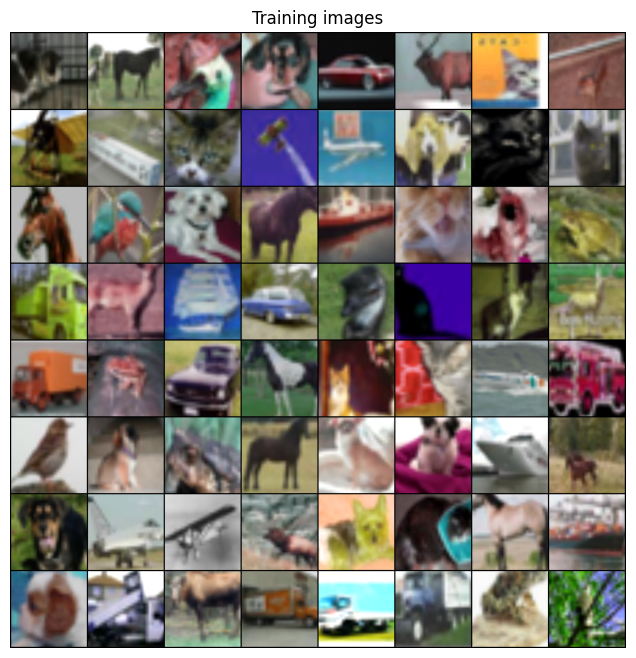

In [13]:
for images, labels in train_loader:  
    break

plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Training images")
plt.imshow(np.transpose(torchvision.utils.make_grid(
    images[:64], 
    padding=2,
    normalize=True),
    (1, 2, 0)))
plt.show()

In [9]:
def train_one_epoch(model, loader, optimizer, criterion, acc_metric, device):
    model.train()
    acc_metric.reset()
    total_loss = 0.0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        acc_metric.update(logits, labels)

    return total_loss / len(loader.dataset), acc_metric.compute().item()


def evaluate(model, loader, criterion, acc_metric, device):
    model.eval()
    acc_metric.reset()
    total_loss = 0.0

    with torch.inference_mode():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            total_loss += criterion(logits, labels).item() * labels.size(0)
            acc_metric.update(logits, labels)

    return total_loss / len(loader.dataset), acc_metric.compute().item()


In [10]:
torch.manual_seed(123)
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model     = model.to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

train_acc = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
val_acc   = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)

writer = SummaryWriter(log_dir="logs/resnet18-augmented")

dummy = torch.zeros(1, 3, 128, 128).to(device)
writer.add_graph(model, dummy)

In [14]:
MAX_EPOCHS = 5

for epoch in range(1, MAX_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, train_acc, device)
    vl_loss, vl_acc = evaluate(model, val_loader, criterion, val_acc, device)

    writer.add_scalars("Loss",     {"train": tr_loss, "val": vl_loss}, epoch)
    writer.add_scalars("Accuracy", {"train": tr_acc,  "val": vl_acc},  epoch)

    print(f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
          f"Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f} | "
          f"Val Loss: {vl_loss:.4f}  Acc: {vl_acc:.4f}")

writer.close()

Epoch 01/5 | Train Loss: 1.5899  Acc: 0.4149 | Val Loss: 1.4226  Acc: 0.4886
Epoch 02/5 | Train Loss: 1.3379  Acc: 0.5186 | Val Loss: 1.3393  Acc: 0.5328
Epoch 03/5 | Train Loss: 1.1126  Acc: 0.6046 | Val Loss: 1.1424  Acc: 0.5938
Epoch 04/5 | Train Loss: 0.9533  Acc: 0.6657 | Val Loss: 1.0119  Acc: 0.6500
Epoch 05/5 | Train Loss: 0.8381  Acc: 0.7070 | Val Loss: 0.8059  Acc: 0.7218


In [ ]:
test_acc = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
te_loss, te_acc = evaluate(model, test_loader, criterion, test_acc, device)
print(f"\nTest Loss: {te_loss:.4f} | Test Accuracy: {te_acc:.4f}")